# Predikcija srčanog udara — SIAP projekat

**Autori:** Marija Tadić (E9 12/2024), Nevena Đukin (E2 145/2024)

Ovaj notebook implementira ceo pipeline iz predloga projekta: predikciju srčanih
oboljenja primenom mašinskog učenja nad **dva nezavisna skupa podataka** —
*Cleveland Heart Disease* i *Framingham Heart Study*.

### Važna metodološka napomena
Cleveland i Framingham se **NE spajaju** i njihovi rezultati se **ne porede direktno**
preko jedne metrike. Razlog:
- **Cleveland** je *dijagnostički* problem — `target` = da li pacijent trenutno ima
  srčano oboljenje (na osnovu kliničkih nalaza tipa EKG, ST-depresija, tip bola u grudima).
- **Framingham** je *prognostički* problem — `TenYearCHD` = rizik da pacijent razvije
  srčano oboljenje **u narednih 10 godina** (na osnovu životnih i bazičnih kliničkih faktora).

To su različiti zadaci sa različitim feature space-om i različitom baznom stopom pozitiva,
pa se vode kao dva odvojena eksperimenta i porede **na nivou zaključaka** (koji faktori dominiraju,
kako se ponaša balansiranje klasa), a ne na nivou apsolutnog F1/AUC.

### Druga napomena — redosled SHAP analize
U predlogu je SHAP naveden kao *inicijalna* analiza. SHAP je post-hoc metod i zahteva
**istreniran model**, pa inicijalnu analizu značajnosti atributa radimo statistički
(t-test/Mann-Whitney, χ², mutual information, korelacija), a SHAP primenjujemo **nakon**
treniranja, nad najboljim modelom.


## Sadržaj

0. Setup i konfiguracija
1. Učitavanje podataka (Cleveland + Framingham, odvojeno)
2. EDA i statistička analiza značajnosti atributa
3. Preprocessing pipeline (sa zaštitom od curenja podataka)
4. HRFLM — custom hibridni estimator (Random Forest + linearni model)
5. Definicija modela
6. Evaluaciona funkcija (StratifiedKFold CV + holdout test)
7. Eksperiment: Cleveland
8. Eksperiment: Framingham (+ tretman disbalansa klasa)
9. SHAP interpretabilnost
10. KMeans klasterovanje i profilisanje pacijenata
11. Poređenje dva skupa i zaključak


## 0. Setup i konfiguracija

Ako neki paket nedostaje, otkomentariši i pokreni ćeliju ispod. `ucimlrepo` se koristi
za automatsko preuzimanje Cleveland skupa sa UCI repozitorijuma; `imbalanced-learn` za SMOTE;
`shap` za interpretabilnost; `xgboost` i `catboost` za boosting modele.


In [1]:
#!pip install -q ucimlrepo scikit-learn pandas numpy matplotlib seaborn scipy \
#               imbalanced-learn shap xgboost catboost

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import mutual_info_classif

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve,
                             precision_recall_curve, silhouette_score,
                             ConfusionMatrixDisplay)

from sklearn.base import BaseEstimator, ClassifierMixin

# Boosting i ostali eksterni paketi (degradiramo graciozno ako nedostaju)
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception as e:
    HAS_XGB = False
    print("XGBoost nije dostupan:", e)

try:
    from catboost import CatBoostClassifier
    HAS_CAT = True
except Exception as e:
    HAS_CAT = False
    print("CatBoost nije dostupan:", e)

try:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import SMOTE
    HAS_IMB = True
except Exception as e:
    HAS_IMB = False
    print("imbalanced-learn nije dostupan:", e)

try:
    import shap
    HAS_SHAP = True
except Exception as e:
    HAS_SHAP = False
    print("SHAP nije dostupan:", e)

# Globalni seed za reproduktivnost — koristimo ga svuda
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 50)

## 1. Učitavanje podataka

### 1.1 Cleveland Heart Disease (UCI, id=45)
303 zapisa, 13 atributa + ciljna varijabla `num` (0–4). Vrednost `num > 0` znači prisustvo
oboljenja, pa ciljnu varijablu **binarizujemo** na {0, 1}. Nedostajuće vrednosti postoje u
kolonama `ca` i `thal`.


In [3]:
import os

def load_cleveland(local="../data/processed.cleveland.data"):
    cols = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
            "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"]
    # 1) Lokalni fajl priložen u data/ (radi offline) — preferirani put
    if os.path.exists(local):
        df = pd.read_csv(local, header=None, names=cols, na_values="?")
        y = (df["num"] > 0).astype(int)
        return df.drop(columns=["num"]), y
    # 2) ucimlrepo (automatsko preuzimanje sa UCI repozitorijuma)
    try:
        from ucimlrepo import fetch_ucirepo
        heart = fetch_ucirepo(id=45)
        X = heart.data.features.copy()
        y = (heart.data.targets.iloc[:, 0] > 0).astype(int)
        return X, y
    except Exception as e:
        print("Lokalni fajl ne postoji i ucimlrepo nije uspeo, pokušavam URL:", e)
        # 3) direktan UCI URL (zahteva internet)
        url = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
               "heart-disease/processed.cleveland.data")
        df = pd.read_csv(url, header=None, names=cols, na_values="?")
        y = (df["num"] > 0).astype(int)
        return df.drop(columns=["num"]), y

X_cl, y_cl = load_cleveland()
print("Cleveland oblik:", X_cl.shape)
print("Raspodela klasa:\n", y_cl.value_counts(normalize=True).round(3))
X_cl.head()

Cleveland oblik: (303, 13)
Raspodela klasa:
 num
0    0.541
1    0.459
Name: proportion, dtype: float64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0


Definišemo tipove kolona. Iako su `cp`, `restecg`, `slope`, `thal`, `ca` numerički
kodirane, semantički su **kategorijske** (kodovi, ne kontinuirane veličine) i tako ih tretiramo.


In [4]:
# Kontinuirani (numerički) atributi
num_cols_cl = ["age", "trestbps", "chol", "thalach", "oldpeak"]
# Kategorijski atributi (binarni i nominalni kodovi)
cat_cols_cl = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

print("Nedostajuće vrednosti po koloni:")
print(X_cl[num_cols_cl + cat_cols_cl].isna().sum())

Nedostajuće vrednosti po koloni:
age         0
trestbps    0
chol        0
thalach     0
oldpeak     0
sex         0
cp          0
fbs         0
restecg     0
exang       0
slope       0
ca          4
thal        2
dtype: int64


### 1.2 Framingham Heart Study

4240 zapisa, 15 atributa, ciljna varijabla `TenYearCHD`. Skup je **disbalansiran**
(~15% pozitiva), što kasnije tretiramo (`class_weight` / SMOTE). Nedostajuće vrednosti
postoje u više kolona (`glucose`, `education`, `BPMeds`, `totChol`, `cigsPerDay`, `BMI`, `heartRate`).

**Podaci su priloženi** u `data/framingham.csv` (iz Kaggle skupa *Framingham Heart Study*),
pa notebook radi offline. Ako fajl nije tu, preuzmi ga sa Kaggle-a i smesti u `data/`.


In [5]:
def load_framingham(path="../data/framingham.csv"):
    df = pd.read_csv(path)
    # neke verzije imaju kolonu 'male', neke 'Sex_male' / 'gender' — normalizujemo
    if "male" not in df.columns:
        for alt in ["Sex_male", "gender", "sex"]:
            if alt in df.columns:
                df = df.rename(columns={alt: "male"})
                break
    return df

try:
    df_fr = load_framingham()
    y_fr = df_fr["TenYearCHD"].astype(int)
    X_fr = df_fr.drop(columns=["TenYearCHD"])
    print("Framingham oblik:", X_fr.shape)
    print("Raspodela klasa:\n", y_fr.value_counts(normalize=True).round(3))
    display(X_fr.head())
except FileNotFoundError:
    print("framingham.csv nije pronađen u data/. Preuzmi ga sa Kaggle-a pre pokretanja.")
    X_fr, y_fr = None, None

Framingham oblik: (4240, 15)
Raspodela klasa:
 TenYearCHD
0    0.848
1    0.152
Name: proportion, dtype: float64


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0


In [6]:
# Tipovi kolona za Framingham
num_cols_fr = ["age", "cigsPerDay", "totChol", "sysBP", "diaBP",
               "BMI", "heartRate", "glucose"]
cat_cols_fr = ["male", "education", "currentSmoker", "BPMeds",
               "prevalentStroke", "prevalentHyp", "diabetes"]

if X_fr is not None:
    # zadržavamo samo kolone koje stvarno postoje (robusnost na varijacije skupa)
    num_cols_fr = [c for c in num_cols_fr if c in X_fr.columns]
    cat_cols_fr = [c for c in cat_cols_fr if c in X_fr.columns]
    print("Nedostajuće vrednosti po koloni:")
    print(X_fr[num_cols_fr + cat_cols_fr].isna().sum())

Nedostajuće vrednosti po koloni:
age                  0
cigsPerDay          29
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
male                 0
education          105
currentSmoker        0
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
dtype: int64


## 2. EDA i statistička analiza značajnosti atributa

Cilj: pre modelovanja razumeti raspodele, nedostajuće vrednosti, balans klase i
**koji atributi su statistički povezani sa ishodom**. Ovo je naša „inicijalna analiza"
(umesto SHAP-a, koji dolazi kasnije).


In [7]:
def eda_overview(X, y, num_cols, cat_cols, name=""):
    print("="*70)
    print("EDA pregled:", name)
    print("="*70)
    print("Broj zapisa:", len(X), "| Broj atributa:", X.shape[1])
    print("Balans ciljne varijable:")
    print(y.value_counts(normalize=True).round(3).to_string())

    # Raspodela ciljne varijable
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    sns.countplot(x=y, ax=ax[0])
    ax[0].set_title(f"{name}: raspodela klasa")
    ax[0].set_xlabel("klasa")

    # Nedostajuće vrednosti
    miss = X[num_cols + cat_cols].isna().mean().sort_values(ascending=False)
    miss = miss[miss > 0]
    if len(miss) > 0:
        miss.plot(kind="barh", ax=ax[1])
        ax[1].set_title(f"{name}: udeo nedostajućih")
    else:
        ax[1].text(0.5, 0.5, "Nema nedostajućih", ha="center")
        ax[1].set_axis_off()
    plt.tight_layout(); plt.show()

    # Distribucije numeričkih atributa po klasi
    n = len(num_cols)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 3.5))
    if n == 1: axes = [axes]
    for ax, col in zip(axes, num_cols):
        for cls in sorted(y.unique()):
            sns.kdeplot(X.loc[y == cls, col].dropna(), ax=ax, label=f"klasa {cls}", fill=True, alpha=0.3)
        ax.set_title(col); ax.legend()
    plt.suptitle(f"{name}: numerički atributi po klasi", y=1.05)
    plt.tight_layout(); plt.show()

EDA pregled: Cleveland
Broj zapisa: 303 | Broj atributa: 13
Balans ciljne varijable:
num
0    0.541
1    0.459


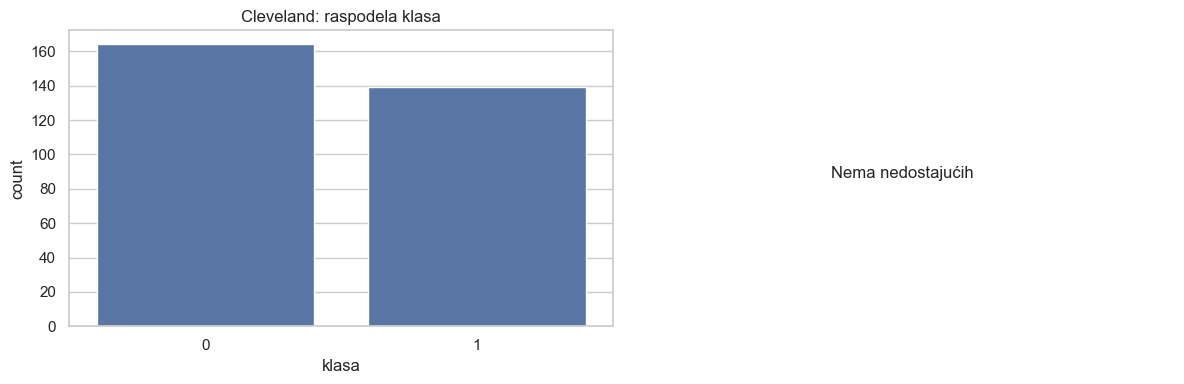

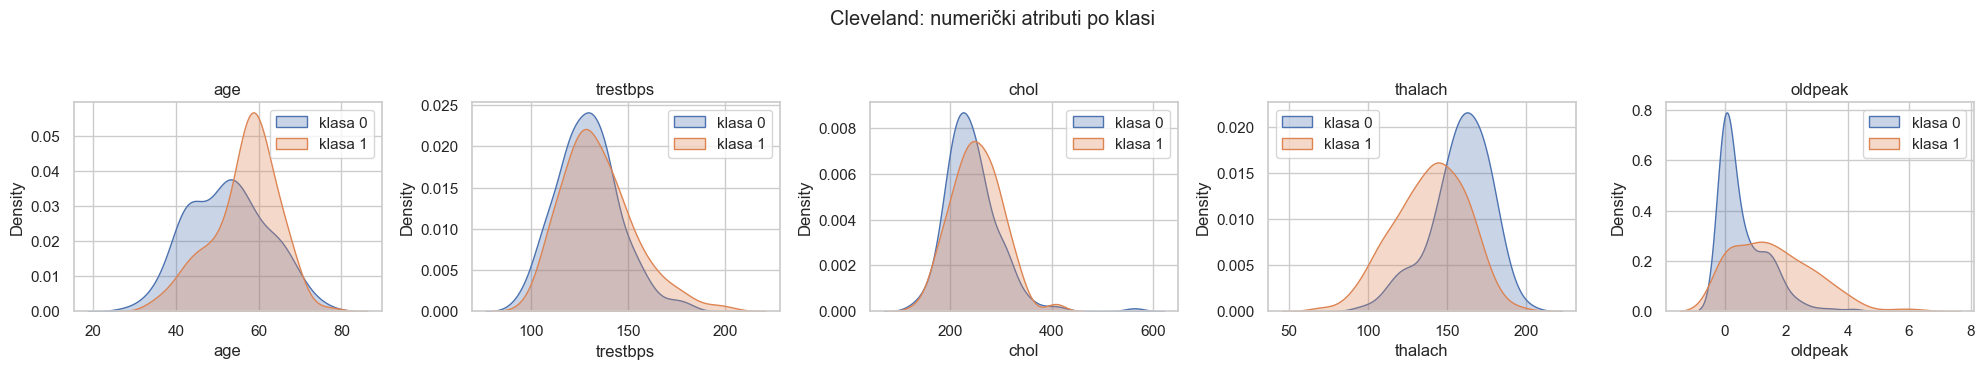

In [8]:
eda_overview(X_cl, y_cl, num_cols_cl, num_cols_cl + [], name="Cleveland")
# napomena: za KDE prikaz koristimo samo numeričke; kategorijske gledamo statistički ispod

EDA pregled: Framingham
Broj zapisa: 4240 | Broj atributa: 15
Balans ciljne varijable:
TenYearCHD
0    0.848
1    0.152


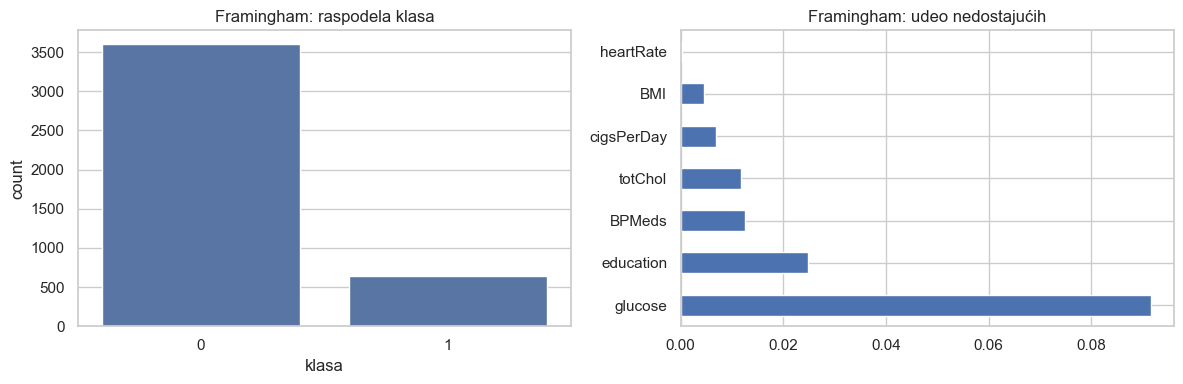

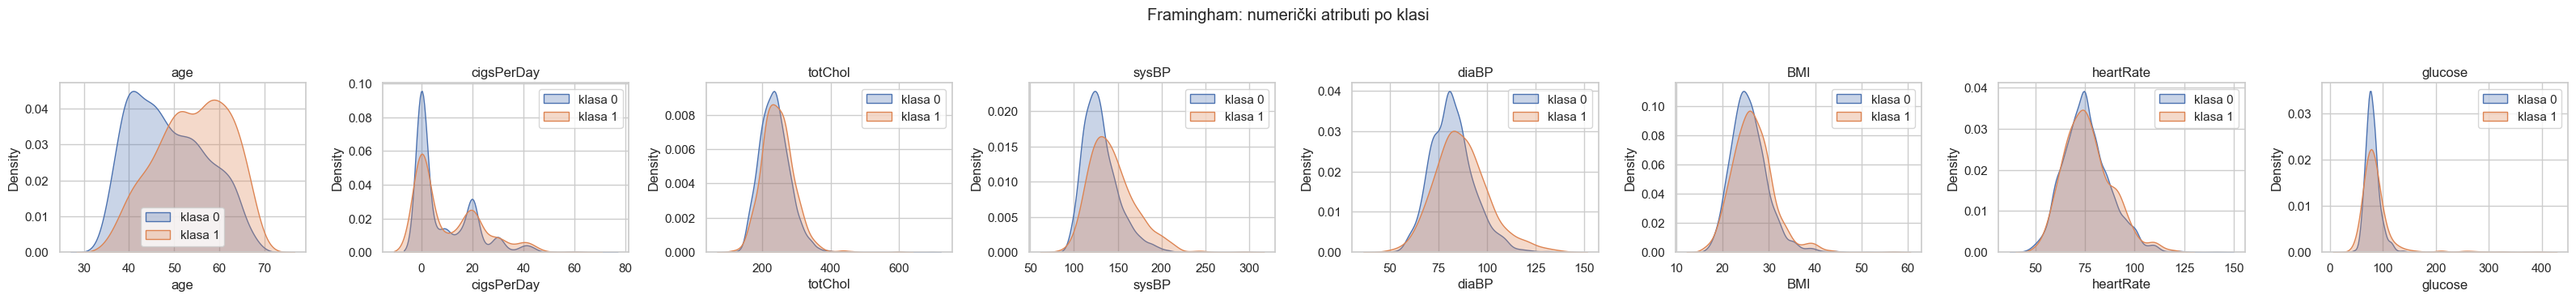

In [9]:
if X_fr is not None:
    eda_overview(X_fr, y_fr, num_cols_fr, cat_cols_fr, name="Framingham")

### 2.1 Statistički testovi značajnosti

- **Numerički atributi:** Mann-Whitney U test (ne pretpostavlja normalnost) razlike
  distribucije atributa između klasa.
- **Kategorijski atributi:** χ² test nezavisnosti.
- **Mutual information:** hvata i nelinearne zavisnosti sa ciljnom varijablom.


In [10]:
def significance_tests(X, y, num_cols, cat_cols, name=""):
    rows = []
    # Numerički -> Mann-Whitney U
    for col in num_cols:
        a = X.loc[y == 1, col].dropna()
        b = X.loc[y == 0, col].dropna()
        if len(a) > 0 and len(b) > 0:
            stat, p = stats.mannwhitneyu(a, b, alternative="two-sided")
            rows.append([col, "numerički", "Mann-Whitney", round(p, 5)])
    # Kategorijski -> chi-square
    for col in cat_cols:
        ct = pd.crosstab(X[col], y)
        if ct.shape[0] > 1:
            chi2, p, dof, _ = stats.chi2_contingency(ct)
            rows.append([col, "kategorijski", "chi-square", round(p, 5)])
    res = pd.DataFrame(rows, columns=["atribut", "tip", "test", "p_value"])
    res = res.sort_values("p_value").reset_index(drop=True)
    res["znacajan_0.05"] = res["p_value"] < 0.05
    print(f"Statistički testovi — {name}")
    return res

sig_cl = significance_tests(X_cl, y_cl, num_cols_cl, cat_cols_cl, "Cleveland")
sig_cl

Statistički testovi — Cleveland


,atribut,tip,test,p_value,znacajan_0.05
0,thalach,numerički,Mann-Whitney,0.00000,True
1,cp,kategorijski,chi-square,0.00000,True
2,sex,kategorijski,chi-square,0.00000,True
3,oldpeak,numerički,Mann-Whitney,0.00000,True
4,thal,kategorijski,chi-square,0.00000,True
5,ca,kategorijski,chi-square,0.00000,True
6,slope,kategorijski,chi-square,0.00000,True
7,exang,kategorijski,chi-square,0.00000,True
8,age,numerički,Mann-Whitney,0.00004,True
9,restecg,kategorijski,chi-square,0.00657,True


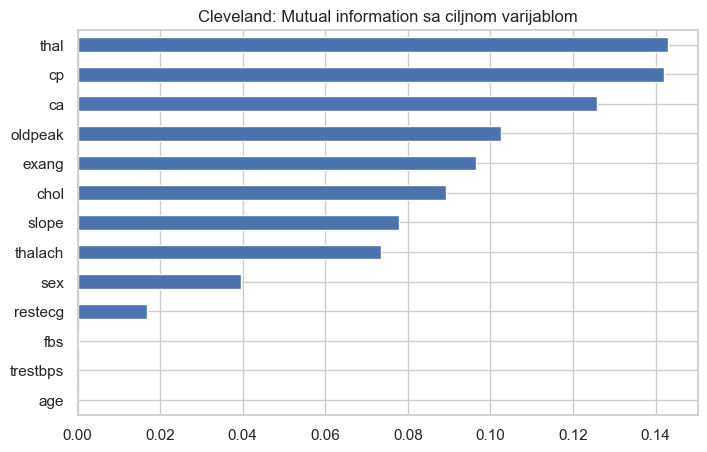

In [11]:
# Mutual information (zahteva imputirane numeričke ulaze) — Cleveland
def quick_mi(X, y, num_cols, cat_cols):
    Xi = X[num_cols + cat_cols].copy()
    for c in num_cols:
        Xi[c] = Xi[c].fillna(Xi[c].median())
    for c in cat_cols:
        Xi[c] = Xi[c].fillna(Xi[c].mode().iloc[0])
    discrete = [Xi.columns.get_loc(c) for c in cat_cols]
    mi = mutual_info_classif(Xi, y, discrete_features=discrete, random_state=RANDOM_STATE)
    return pd.Series(mi, index=Xi.columns).sort_values(ascending=False)

mi_cl = quick_mi(X_cl, y_cl, num_cols_cl, cat_cols_cl)
mi_cl.plot(kind="barh"); plt.gca().invert_yaxis()
plt.title("Cleveland: Mutual information sa ciljnom varijablom"); plt.show()

Statistički testovi — Framingham


,atribut,tip,test,p_value,znacajan_0.05
0,age,numerički,Mann-Whitney,0.00000,True
1,totChol,numerički,Mann-Whitney,0.00000,True
2,sysBP,numerički,Mann-Whitney,0.00000,True
3,diaBP,numerički,Mann-Whitney,0.00000,True
4,BMI,numerički,Mann-Whitney,0.00000,True
5,BPMeds,kategorijski,chi-square,0.00000,True
6,education,kategorijski,chi-square,0.00000,True
7,male,kategorijski,chi-square,0.00000,True
8,diabetes,kategorijski,chi-square,0.00000,True
9,prevalentHyp,kategorijski,chi-square,0.00000,True


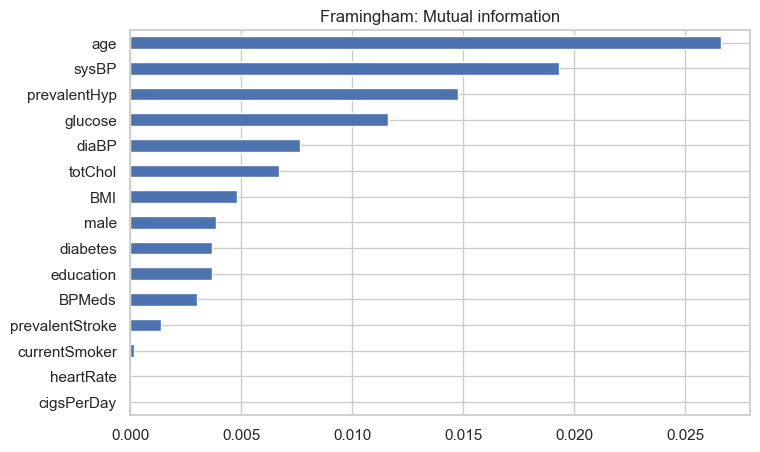

In [12]:
if X_fr is not None:
    sig_fr = significance_tests(X_fr, y_fr, num_cols_fr, cat_cols_fr, "Framingham")
    display(sig_fr)
    mi_fr = quick_mi(X_fr, y_fr, num_cols_fr, cat_cols_fr)
    mi_fr.plot(kind="barh"); plt.gca().invert_yaxis()
    plt.title("Framingham: Mutual information"); plt.show()

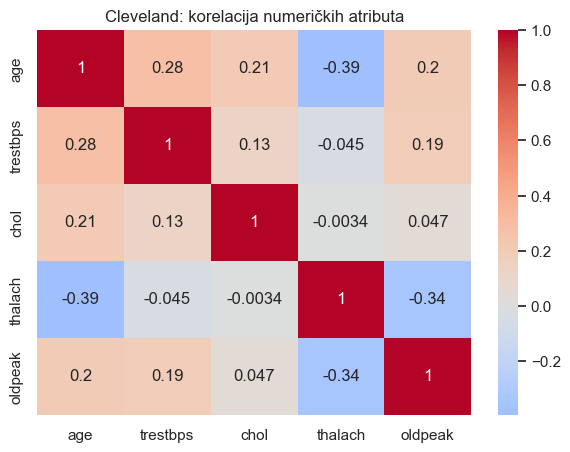

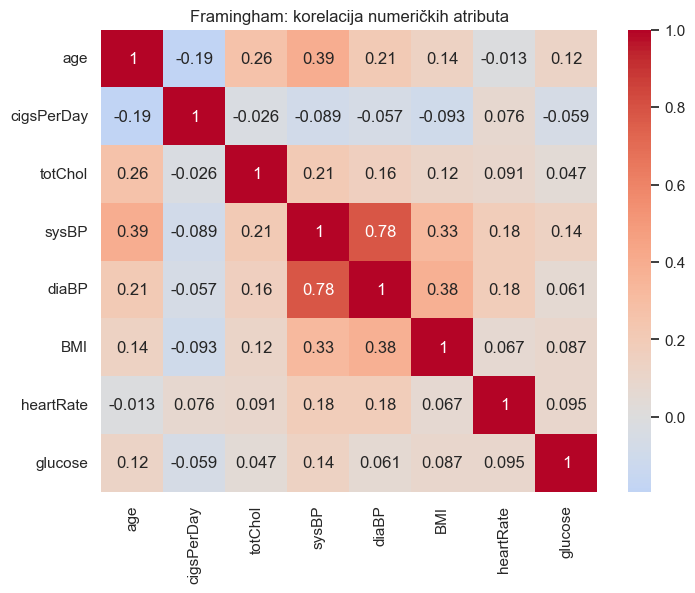

In [13]:
# Korelaciona matrica numeričkih atributa (detekcija multikolinearnosti)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(X_cl[num_cols_cl].corr(), annot=True, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Cleveland: korelacija numeričkih atributa"); plt.show()

if X_fr is not None:
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(X_fr[num_cols_fr].corr(), annot=True, cmap="coolwarm", center=0, ax=ax)
    ax.set_title("Framingham: korelacija numeričkih atributa"); plt.show()
    # napomena: sysBP, diaBP i prevalentHyp su očekivano korelisani

## 3. Preprocessing pipeline

Sve transformacije idu kroz `ColumnTransformer` **unutar** `Pipeline`-a, tako da se
`fit` radi isključivo na trening foldu. Time sprečavamo curenje podataka (data leakage)
prilikom unakrsne validacije.

- numerički: median imputacija + `StandardScaler`
- kategorijski: most-frequent imputacija + `OneHotEncoder` (gust izlaz radi HRFLM/SHAP)


In [14]:
def build_preprocessor(num_cols, cat_cols):
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer([
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ])

## 4. HRFLM — Hybrid Random Forest with Linear Model

HRFLM iz rada [1] (Mohan et al., 2019) nije gotova komponenta u scikit-learn-u, pa ga
implementiramo kao custom estimator. Naša interpretacija hibrida „RF + linearni model":

1. Treniramo `RandomForest` i izračunamo **indeks lista** u koji svaki uzorak pada za svako stablo
   (`rf.apply(X)`) — ovo je nelinearna, naučena reprezentacija prostora.
2. One-hot kodiramo te listove i nad njima treniramo **linearni model** (`LogisticRegression`).

Tako linearni model uči težine nad particijama prostora koje je RF otkrio — kombinacija
nelinearne strukture stabala i interpretabilnog linearnog sloja. Estimator je
scikit-learn kompatibilan (radi unutar `Pipeline`-a, `cross_val_score`, `GridSearchCV`).


In [15]:
class HRFLM(BaseEstimator, ClassifierMixin):
    # Hibrid: RandomForest (leaf embedding) + LogisticRegression
    def __init__(self, n_estimators=200, max_depth=None, C=1.0,
                 class_weight=None, random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.C = C
        self.class_weight = class_weight
        self.random_state = random_state

    def fit(self, X, y):
        X = np.asarray(X)
        self.rf_ = RandomForestClassifier(
            n_estimators=self.n_estimators, max_depth=self.max_depth,
            class_weight=self.class_weight, random_state=self.random_state, n_jobs=-1)
        self.rf_.fit(X, y)
        leaves = self.rf_.apply(X)  # (n_uzoraka, n_stabala)
        self.enc_ = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
        L = self.enc_.fit_transform(leaves)
        self.lr_ = LogisticRegression(
            C=self.C, max_iter=2000, class_weight=self.class_weight,
            random_state=self.random_state)
        self.lr_.fit(L, y)
        self.classes_ = self.rf_.classes_
        return self

    def _embed(self, X):
        X = np.asarray(X)
        return self.enc_.transform(self.rf_.apply(X))

    def predict(self, X):
        return self.lr_.predict(self._embed(X))

    def predict_proba(self, X):
        return self.lr_.predict_proba(self._embed(X))

## 5. Definicija modela

Modeli iz predloga: Logistic Regression (baseline), Naive Bayes, Decision Tree, SVM,
Random Forest, XGBoost, CatBoost i HRFLM. `class_weight` prosleđujemo gde je podržan
(za tretman disbalansa na Framingham-u); XGBoost koristi `scale_pos_weight` koji
računamo posebno.


In [16]:
def get_models(class_weight=None, scale_pos_weight=1.0):
    models = {
        "Logistic Regression": LogisticRegression(
            max_iter=2000, class_weight=class_weight, random_state=RANDOM_STATE),
        "Naive Bayes": GaussianNB(),
        "Decision Tree": DecisionTreeClassifier(
            class_weight=class_weight, random_state=RANDOM_STATE),
        "SVM": SVC(probability=True, class_weight=class_weight, random_state=RANDOM_STATE),
        "Random Forest": RandomForestClassifier(
            n_estimators=300, class_weight=class_weight,
            random_state=RANDOM_STATE, n_jobs=-1),
        "HRFLM": HRFLM(class_weight=class_weight, random_state=RANDOM_STATE),
    }
    if HAS_XGB:
        models["XGBoost"] = XGBClassifier(
            eval_metric="logloss", scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE, n_jobs=-1)
    if HAS_CAT:
        models["CatBoost"] = CatBoostClassifier(
            verbose=0, random_state=RANDOM_STATE,
            auto_class_weights=("Balanced" if class_weight == "balanced" else None))
    return models

## 6. Evaluaciona funkcija

Protokol iz predloga: podela **80/20** (stratifikovano), na trening skupu **5-fold
StratifiedKFold** unakrsna validacija. Primarna metrika je **F1**, uz AUC, preciznost,
odziv i matricu konfuzije. Crtamo ROC i Precision-Recall krive za sve modele
(PR kriva je informativnija kod disbalansa).

`use_smote=True` ubacuje SMOTE **unutar** pipeline-a (samo na trening fold) preko
`imblearn.Pipeline`, čime se izbegava curenje.


In [17]:
def make_pipe(preprocessor, model, use_smote):
    if use_smote:
        if not HAS_IMB:
            raise RuntimeError("imbalanced-learn nije instaliran, a use_smote=True")
        return ImbPipeline([
            ("prep", preprocessor),
            ("smote", SMOTE(random_state=RANDOM_STATE)),
            ("clf", model),
        ])
    return Pipeline([("prep", preprocessor), ("clf", model)])


def evaluate_models(X, y, num_cols, cat_cols, use_smote=False,
                    class_weight=None, name=""):
    X = X[num_cols + cat_cols].copy()
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

    # scale_pos_weight za XGBoost (samo kada balansiramo)
    pos = (y_tr == 1).sum(); neg = (y_tr == 0).sum()
    spw = (neg / pos) if (class_weight == "balanced" and pos > 0) else 1.0

    models = get_models(class_weight=class_weight, scale_pos_weight=spw)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    results, fitted, proba_store = [], {}, {}
    for mname, model in models.items():
        prep = build_preprocessor(num_cols, cat_cols)
        pipe = make_pipe(prep, model, use_smote)
        # CV F1 na trening skupu
        cv_f1 = cross_val_score(pipe, X_tr, y_tr, cv=skf, scoring="f1", n_jobs=-1)
        # finalni fit + evaluacija na holdout test skupu
        pipe.fit(X_tr, y_tr)
        y_pred = pipe.predict(X_te)
        y_proba = pipe.predict_proba(X_te)[:, 1]
        results.append({
            "Model": mname,
            "CV F1 (mean)": round(cv_f1.mean(), 4),
            "CV F1 (std)": round(cv_f1.std(), 4),
            "Test F1": round(f1_score(y_te, y_pred), 4),
            "Preciznost": round(precision_score(y_te, y_pred, zero_division=0), 4),
            "Odziv": round(recall_score(y_te, y_pred), 4),
            "Tačnost": round(accuracy_score(y_te, y_pred), 4),
            "AUC": round(roc_auc_score(y_te, y_proba), 4),
        })
        fitted[mname] = pipe
        proba_store[mname] = y_proba

    res_df = pd.DataFrame(results).sort_values("Test F1", ascending=False).reset_index(drop=True)

    # ROC i PR krive za sve modele
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    for mname, yp in proba_store.items():
        fpr, tpr, _ = roc_curve(y_te, yp)
        ax[0].plot(fpr, tpr, label=f"{mname} (AUC={roc_auc_score(y_te, yp):.3f})")
        prec, rec, _ = precision_recall_curve(y_te, yp)
        ax[1].plot(rec, prec, label=mname)
    ax[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
    ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].set_title(f"{name}: ROC")
    ax[0].legend(fontsize=8)
    ax[1].set_xlabel("Odziv"); ax[1].set_ylabel("Preciznost")
    ax[1].set_title(f"{name}: Precision-Recall"); ax[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()

    return res_df, fitted, (X_tr, X_te, y_tr, y_te)

In [18]:
def plot_confusion(fitted, data, model_name, name=""):
    X_tr, X_te, y_tr, y_te = data
    y_pred = fitted[model_name].predict(X_te)
    cm = confusion_matrix(y_te, y_pred)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues", colorbar=False)
    plt.title(f"{name}: matrica konfuzije — {model_name}"); plt.show()

## 7. Eksperiment: Cleveland

Cleveland je skoro balansiran, pa ne koristimo SMOTE niti `class_weight`.


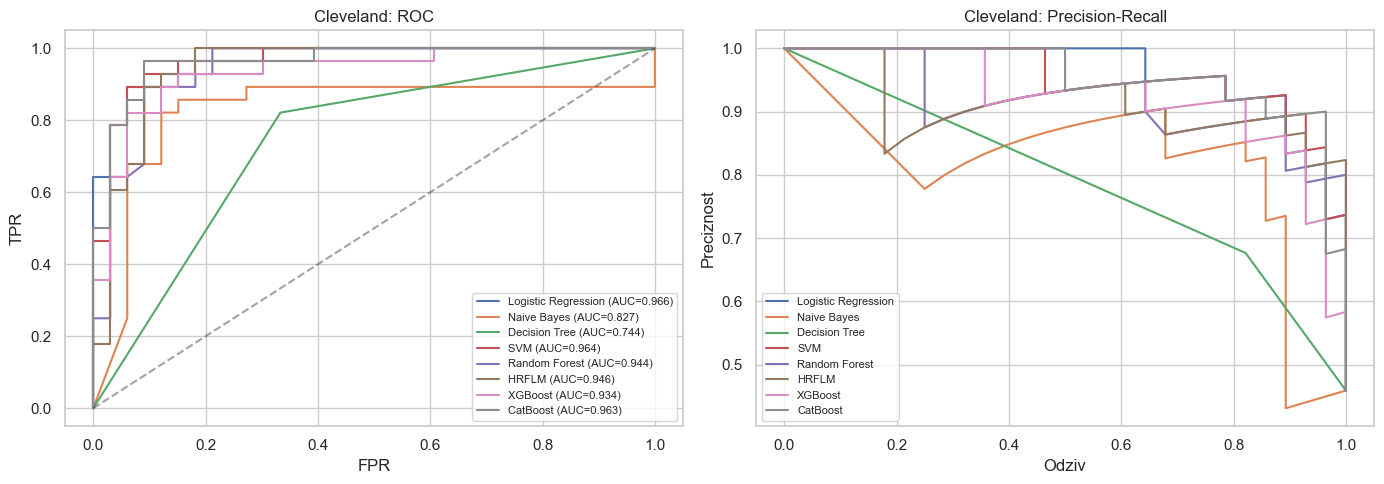

,Model,CV F1 (mean),CV F1 (std),Test F1,Preciznost,Odziv,Tačnost,AUC
0,CatBoost,0.7808,0.0204,0.9000,0.8438,0.9643,0.9016,0.9632
1,Logistic Regression,0.8245,0.0069,0.8814,0.8387,0.9286,0.8852,0.9665
2,HRFLM,0.7719,0.0234,0.8814,0.8387,0.9286,0.8852,0.9459
3,SVM,0.7893,0.0271,0.8814,0.8387,0.9286,0.8852,0.9643
4,Random Forest,0.7958,0.0363,0.8667,0.8125,0.9286,0.8689,0.9443
5,XGBoost,0.7707,0.0269,0.8387,0.7647,0.9286,0.8361,0.9340
6,Naive Bayes,0.7495,0.0215,0.7463,0.6410,0.8929,0.7213,0.8268
7,Decision Tree,0.6768,0.0420,0.7419,0.6765,0.8214,0.7377,0.7440


In [19]:
res_cl, fitted_cl, data_cl = evaluate_models(
    X_cl, y_cl, num_cols_cl, cat_cols_cl, use_smote=False, class_weight=None, name="Cleveland")
res_cl

Najbolji model (Cleveland): CatBoost


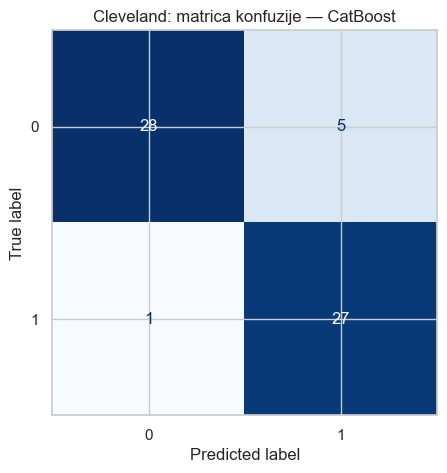

In [20]:
best_cl = res_cl.iloc[0]["Model"]
print("Najbolji model (Cleveland):", best_cl)
plot_confusion(fitted_cl, data_cl, best_cl, name="Cleveland")

## 8. Eksperiment: Framingham (+ tretman disbalansa)

Framingham je disbalansiran (~15% pozitiva). Poredimo tri strategije:
1. **bez tretmana** (referenca),
2. **`class_weight="balanced"`**,
3. **SMOTE** (sintetičko uzorkovanje manjinske klase, unutar CV folda).

Kod disbalansa gledamo prevashodno **odziv (recall)** i **PR-AUC**, jer je cilj
minimizovati lažno negativne (propušteni rizični pacijenti).


>>> Framingham — bez tretmana disbalansa


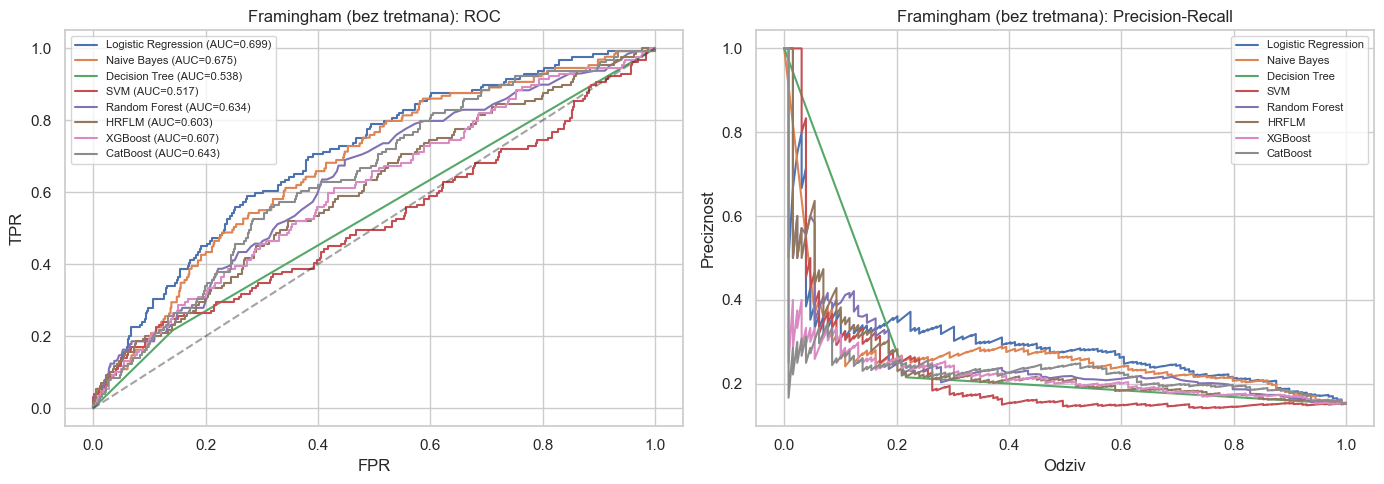

,Model,CV F1 (mean),CV F1 (std),Test F1,Preciznost,Odziv,Tačnost,AUC
0,Decision Tree,0.2760,0.0224,0.2162,0.2154,0.2171,0.7606,0.5376
1,Naive Bayes,0.2559,0.0234,0.1693,0.2667,0.1240,0.8149,0.6754
2,HRFLM,0.2067,0.0313,0.1585,0.3714,0.1008,0.8373,0.6031
3,XGBoost,0.1992,0.0342,0.1512,0.3023,0.1008,0.8278,0.6072
4,CatBoost,0.1622,0.0383,0.1039,0.3200,0.0620,0.8373,0.6426
5,Random Forest,0.1306,0.0112,0.0966,0.4375,0.0543,0.8455,0.6344
6,Logistic Regression,0.1640,0.0478,0.0822,0.3529,0.0465,0.8420,0.6994
7,SVM,0.0334,0.0216,0.0597,0.8000,0.0310,0.8514,0.5170


In [21]:
if X_fr is not None:
    print(">>> Framingham — bez tretmana disbalansa")
    res_fr_base, fitted_fr_base, data_fr = evaluate_models(
        X_fr, y_fr, num_cols_fr, cat_cols_fr,
        use_smote=False, class_weight=None, name="Framingham (bez tretmana)")
    display(res_fr_base)

>>> Framingham — class_weight='balanced'


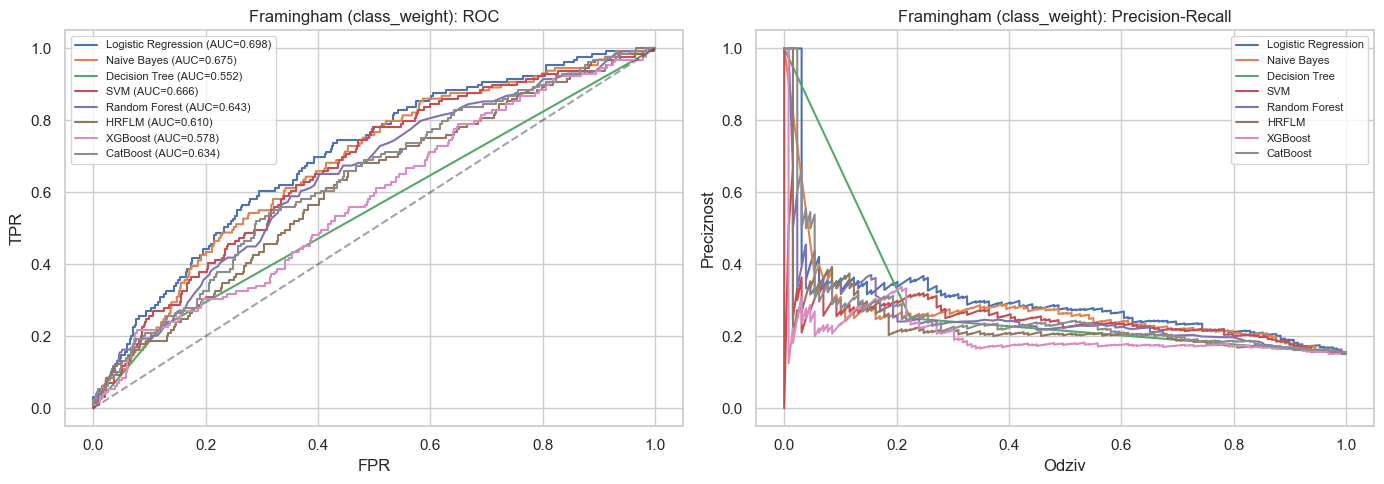

,Model,CV F1 (mean),CV F1 (std),Test F1,Preciznost,Odziv,Tačnost,AUC
0,Logistic Regression,0.3947,0.0311,0.3586,0.2549,0.6047,0.6710,0.6981
1,SVM,0.3823,0.0371,0.3190,0.2302,0.5194,0.6627,0.6657
2,CatBoost,0.3463,0.0200,0.2642,0.2222,0.3256,0.7241,0.6340
3,XGBoost,0.2580,0.0239,0.2445,0.2800,0.2171,0.7960,0.5785
4,Decision Tree,0.2046,0.0285,0.2367,0.2500,0.2248,0.7795,0.5519
5,HRFLM,0.2527,0.0246,0.1808,0.3333,0.1240,0.8290,0.6101
6,Naive Bayes,0.2559,0.0234,0.1693,0.2667,0.1240,0.8149,0.6754
7,Random Forest,0.0736,0.0228,0.0441,0.4286,0.0233,0.8467,0.6430


In [22]:
if X_fr is not None:
    print(">>> Framingham — class_weight='balanced'")
    res_fr_cw, fitted_fr_cw, _ = evaluate_models(
        X_fr, y_fr, num_cols_fr, cat_cols_fr,
        use_smote=False, class_weight="balanced", name="Framingham (class_weight)")
    display(res_fr_cw)

>>> Framingham — SMOTE


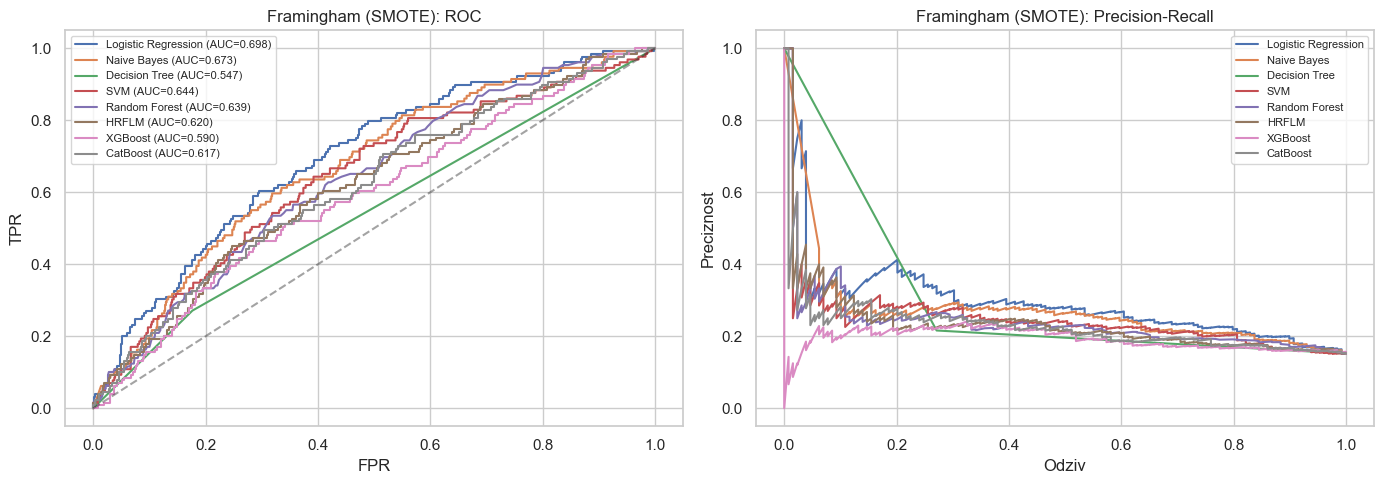

,Model,CV F1 (mean),CV F1 (std),Test F1,Preciznost,Odziv,Tačnost,AUC
0,Logistic Regression,0.3802,0.0288,0.3587,0.2524,0.6202,0.6627,0.6977
1,SVM,0.3194,0.0165,0.3177,0.2392,0.4729,0.6910,0.6443
2,Naive Bayes,0.3298,0.0369,0.2734,0.2756,0.2713,0.7807,0.6729
3,Decision Tree,0.2486,0.0190,0.2405,0.2160,0.2713,0.7394,0.5473
4,CatBoost,0.2676,0.0232,0.2000,0.2593,0.1628,0.8019,0.6169
5,Random Forest,0.2687,0.0223,0.1827,0.2405,0.1473,0.7995,0.6387
6,XGBoost,0.2303,0.0181,0.1818,0.2198,0.1550,0.7877,0.5904
7,HRFLM,0.2532,0.0342,0.1753,0.2615,0.1318,0.8113,0.6200


In [23]:
if X_fr is not None and HAS_IMB:
    print(">>> Framingham — SMOTE")
    res_fr_smote, fitted_fr_smote, data_fr_smote = evaluate_models(
        X_fr, y_fr, num_cols_fr, cat_cols_fr,
        use_smote=True, class_weight=None, name="Framingham (SMOTE)")
    display(res_fr_smote)

In [24]:
# Poređenje tri strategije po odzivu i F1 (na primeru najboljeg modela)
if X_fr is not None:
    comp = pd.DataFrame({
        "bez tretmana": res_fr_base.set_index("Model")[["Test F1", "Odziv", "AUC"]].mean(),
        "class_weight": res_fr_cw.set_index("Model")[["Test F1", "Odziv", "AUC"]].mean(),
    })
    if HAS_IMB:
        comp["SMOTE"] = res_fr_smote.set_index("Model")[["Test F1", "Odziv", "AUC"]].mean()
    print("Prosek metrika preko svih modela po strategiji:")
    display(comp.round(3))

Prosek metrika preko svih modela po strategiji:


,bez tretmana,class_weight,SMOTE
Test F1,0.130,0.227,0.241
Odziv,0.092,0.270,0.279
AUC,0.615,0.632,0.629


## 9. SHAP interpretabilnost

SHAP primenjujemo **nakon** treniranja, nad najboljim tree-based modelom
(`TreeExplainer`). Dobijamo:
- *summary plot* — globalni uticaj i smer svakog atributa,
- rang-listu najuticajnijih atributa,
koje poredimo sa statističkom analizom iz koraka 2.


SHAP nad modelom: XGBoost


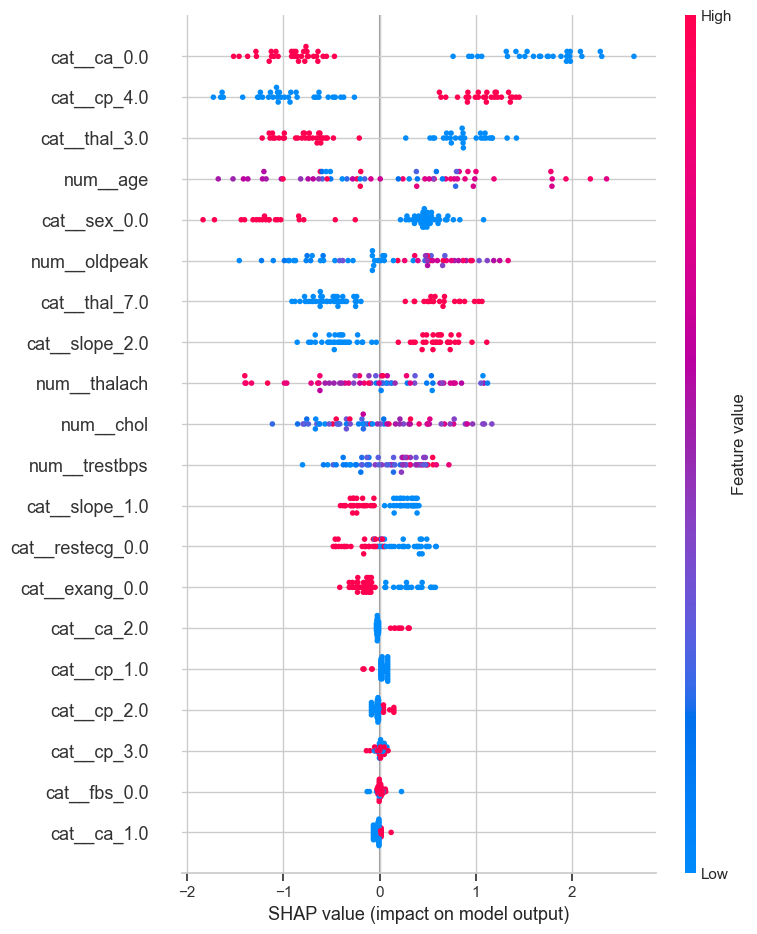

'XGBoost'

In [25]:
def run_shap(fitted, data, num_cols, cat_cols, prefer=("XGBoost", "CatBoost", "Random Forest")):
    if not HAS_SHAP:
        print("SHAP nije dostupan."); return
    X_tr, X_te, y_tr, y_te = data
    model_name = next((m for m in prefer if m in fitted), None)
    if model_name is None:
        print("Nema pogodnog tree modela za TreeExplainer."); return
    pipe = fitted[model_name]
    prep = pipe.named_steps["prep"]
    clf = pipe.named_steps["clf"]
    X_te_t = prep.transform(X_te)
    feat_names = prep.get_feature_names_out()
    explainer = shap.TreeExplainer(clf)
    sv = explainer.shap_values(X_te_t)
    # za binarnu klasifikaciju neki modeli vraćaju listu [klasa0, klasa1]
    if isinstance(sv, list):
        sv = sv[1]
    print(f"SHAP nad modelom: {model_name}")
    shap.summary_plot(sv, X_te_t, feature_names=feat_names, show=True)
    return model_name

run_shap(fitted_cl, data_cl, num_cols_cl, cat_cols_cl)

SHAP nad modelom: XGBoost


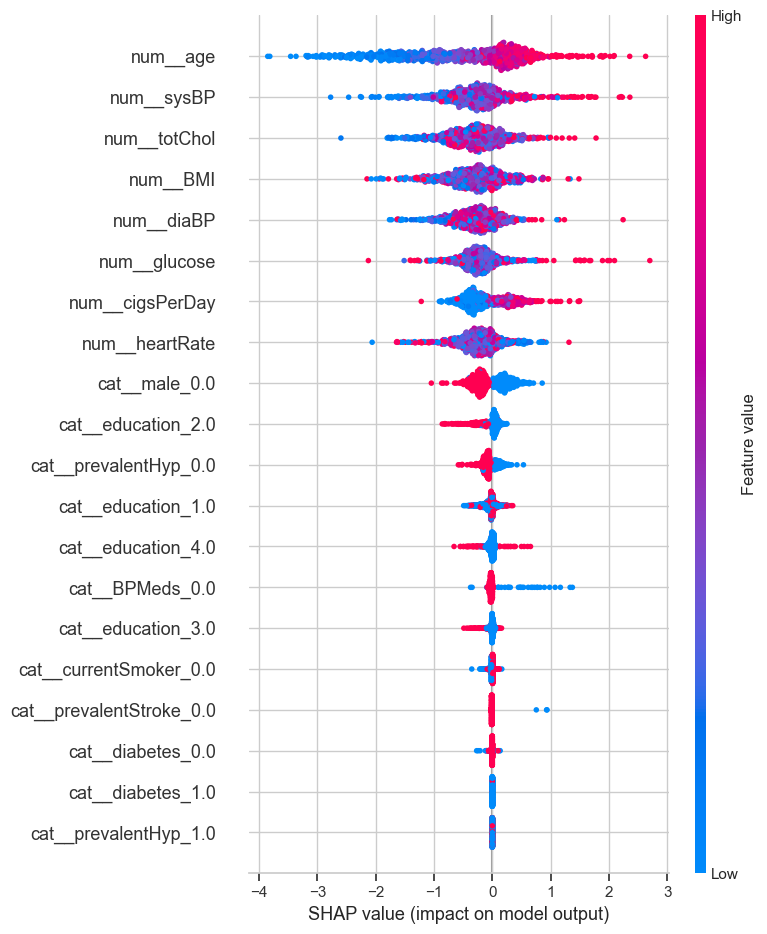

In [26]:
if X_fr is not None:
    run_shap(fitted_fr_cw, data_fr, num_cols_fr, cat_cols_fr)

## 10. KMeans klasterovanje i profilisanje pacijenata

Nenadgledano grupisanje pacijenata po sličnim karakteristikama. Radimo na
**skaliranim** atributima (bez ciljne varijable). Broj klastera biramo kombinacijom
*elbow* metode (inercija) i *silhouette* skora, zatim profilišemo klastere u odnosu
na ciljnu varijablu i ključne atribute.


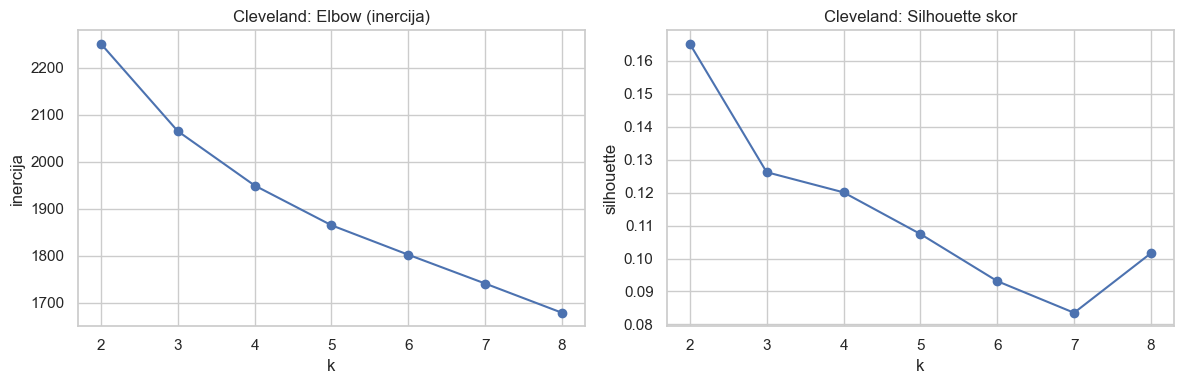

Cleveland: izabrano k = 2 (max silhouette)
Cleveland: udeo pozitiva po klasteru:


klaster
0    0.745
1    0.223
Name: target, dtype: float64

Cleveland: prosečne vrednosti numeričkih atributa po klasteru:


,age,trestbps,chol,thalach,oldpeak
klaster,,,,,
0,60.02,136.86,257.01,133.62,1.75
1,49.83,127.42,238.17,162.80,0.45


In [27]:
def kmeans_analysis(X, y, num_cols, cat_cols, name=""):
    prep = build_preprocessor(num_cols, cat_cols)
    Xk = prep.fit_transform(X[num_cols + cat_cols])

    Ks = range(2, 9)
    inertias, sils = [], []
    for k in Ks:
        km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
        labels = km.fit_predict(Xk)
        inertias.append(km.inertia_)
        sils.append(silhouette_score(Xk, labels))

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(list(Ks), inertias, "o-"); ax[0].set_title(f"{name}: Elbow (inercija)")
    ax[0].set_xlabel("k"); ax[0].set_ylabel("inercija")
    ax[1].plot(list(Ks), sils, "o-"); ax[1].set_title(f"{name}: Silhouette skor")
    ax[1].set_xlabel("k"); ax[1].set_ylabel("silhouette")
    plt.tight_layout(); plt.show()

    best_k = list(Ks)[int(np.argmax(sils))]
    print(f"{name}: izabrano k = {best_k} (max silhouette)")

    km = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE)
    clusters = km.fit_predict(Xk)

    # Profilisanje: udeo pozitiva i prosečne vrednosti ključnih numeričkih atributa po klasteru
    prof = X[num_cols].copy()
    prof["klaster"] = clusters
    prof["target"] = y.values
    summary = prof.groupby("klaster").agg(
        ["mean"]).round(2)
    rate = prof.groupby("klaster")["target"].mean().round(3)
    print(f"{name}: udeo pozitiva po klasteru:")
    display(rate)
    print(f"{name}: prosečne vrednosti numeričkih atributa po klasteru:")
    display(prof.groupby("klaster")[num_cols].mean().round(2))
    return clusters

_ = kmeans_analysis(X_cl, y_cl, num_cols_cl, cat_cols_cl, name="Cleveland")

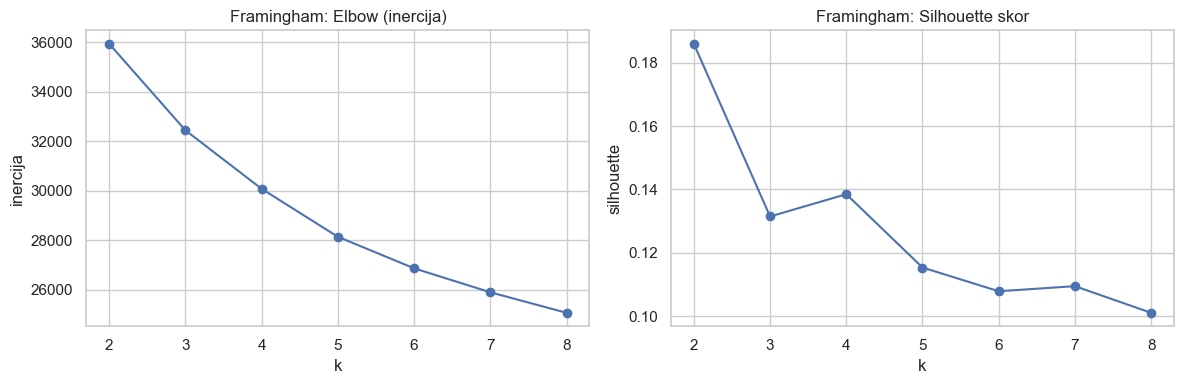

Framingham: izabrano k = 2 (max silhouette)
Framingham: udeo pozitiva po klasteru:


klaster
0    0.105
1    0.236
Name: target, dtype: float64

Framingham: prosečne vrednosti numeričkih atributa po klasteru:


,age,cigsPerDay,totChol,sysBP,diaBP,BMI,heartRate,glucose
klaster,,,,,,,,
0,46.80,10.68,227.4,120.47,77.09,24.58,74.07,79.22
1,54.56,6.00,253.4,153.68,93.33,27.99,79.12,86.87


In [28]:
if X_fr is not None:
    _ = kmeans_analysis(X_fr, y_fr, num_cols_fr, cat_cols_fr, name="Framingham")

## 11. Poređenje dva skupa i zaključak

**Šta poredimo (i šta NE):**
- Ne poredimo apsolutni F1/AUC između Cleveland-a i Framingham-a — to su različiti zadaci
  (dijagnostika sadašnjeg stanja vs. 10-godišnja prognoza), različit feature space i različita
  bazna stopa pozitiva.
- Poredimo: koji tip modela dominira na svakom skupu, ponašanje pri disbalansu (Framingham),
  i poklapanje statističke analize (korak 2) sa SHAP rang-listom (korak 9).

**Očekivani nalazi (popuniti stvarnim brojevima nakon pokretanja):**
- Cleveland: boosting/RF modeli i HRFLM tipično najbolji; mali skup → obavezna unakrsna validacija
  zbog varijanse.
- Framingham: disbalans presudan; `class_weight`/SMOTE značajno podižu odziv uz pad preciznosti —
  kompromis se bira prema cilju (minimizacija propuštenih rizičnih pacijenata).

**Ograničenja:** mali Cleveland skup (303 zapisa) → visoka varijansa; HRFLM je naša interpretacija
hibrida iz [1] (leaf-embedding + linearni model), ne doslovna replika; SHAP nad Framingham-om
treba čitati u svetlu disbalansa.

> Tabele rezultata (`res_cl`, `res_fr_base`, `res_fr_cw`, `res_fr_smote`) su gotov materijal za
> poglavlje *Rezultati* u izveštaju; ROC/PR/konfuzione matrice i SHAP grafici idu kao slike.
